# Statistical analysis: performance vs environment

Uses `results_with_environment.csv` (from 01_join_results_environment). This notebook is **points-first** and assumes filtering to **Finals** and rows with non-null `points`. Correlations between points and environment (temperature, pressure, WBGT, etc.), plus visualizations.

In [6]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
DF_PATH = PROCESSED / "results_with_environment.csv"

df = pd.read_csv(DF_PATH)
print(df.shape)
df.head()

(4846, 28)


,meet_id,person_id,race_start_time,discipline_name,gender,phase,points,time_str,rank,athlete_name,...,elevation,timezone,temperature,dewpoint,wind_speed,pressure,relative_humidity,wbgt,city,country
0,oly_2008,93b926bc-5bb2-41a1-8116-68407f294686,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,1025.0,52.54,1.0,Aaron PEIRSOL,...,43,Asia/Shanghai,24.511201,19.36166,1.283588,996.20059,73.07979,25.211736,Beijing,China
1,oly_2008,18fbe8bb-dd04-4f33-a4af-533ff6a02f9c,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,992.0,53.11,2.0,Matt GREVERS,...,43,Asia/Shanghai,24.511201,19.36166,1.283588,996.20059,73.07979,25.211736,Beijing,China
2,oly_2008,e5312f2e-d574-440e-9bd1-026e8af0bf90,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,988.0,53.18,3.0,Arkady VYATCHANIN,...,43,Asia/Shanghai,24.511201,19.36166,1.283588,996.20059,73.07979,25.211736,Beijing,China
3,oly_2008,a42aa3f5-7f2c-4cba-938b-031b06b5c4d4,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,988.0,53.18,3.0,Hayden STOECKEL,...,43,Asia/Shanghai,24.511201,19.36166,1.283588,996.20059,73.07979,25.211736,Beijing,China
4,oly_2008,91dd7ae2-4c45-4975-8f79-dc808ddf3fd1,2008-08-12T02:31:00,Men's 100m Backstroke,Men,Finals,981.0,53.31,5.0,Ashley DELANEY,...,43,Asia/Shanghai,24.511201,19.36166,1.283588,996.20059,73.07979,25.211736,Beijing,China


## Event-level aggregates

Compare mean race time per (meet, discipline) so each meet–event is one point; then correlate with environment.

In [7]:
# One row per (meet_id, discipline_name, gender): mean points and env (same for all rows in meet)
agg = df.groupby(["meet_id", "discipline_name", "gender"], as_index=False).agg(
    points=("points", "mean"),
    n=("points", "count"),
    temperature=("temperature", "first"),
    pressure=("pressure", "first"),
    wbgt=("wbgt", "first"),
    elevation=("elevation", "first"),
    relative_humidity=("relative_humidity", "first"),
)
agg = agg[agg["n"] >= 3]  # at least 3 finishers per event
print(agg.shape)
agg.head(10)

(526, 10)


,meet_id,discipline_name,gender,points,n,temperature,pressure,wbgt,elevation,relative_humidity
0,oly_2008,Men's 100m Backstroke,Men,983.125,8,24.511201,996.20059,25.211736,43,73.07979
1,oly_2008,Men's 100m Breaststroke,Men,997.875,8,24.511201,996.20059,25.211736,43,73.07979
2,oly_2008,Men's 100m Butterfly,Men,988.125,8,24.511201,996.20059,25.211736,43,73.07979
3,oly_2008,Men's 100m Freestyle,Men,986.625,8,24.511201,996.20059,25.211736,43,73.07979
4,oly_2008,Men's 1500m Freestyle,Men,980.250,8,24.511201,996.20059,25.211736,43,73.07979
5,oly_2008,Men's 200m Backstroke,Men,993.250,8,24.511201,996.20059,25.211736,43,73.07979
6,oly_2008,Men's 200m Breaststroke,Men,985.125,8,24.511201,996.20059,25.211736,43,73.07979
7,oly_2008,Men's 200m Butterfly,Men,998.250,8,24.511201,996.20059,25.211736,43,73.07979
8,oly_2008,Men's 200m Freestyle,Men,979.750,8,24.511201,996.20059,25.211736,43,73.07979
9,oly_2008,Men's 200m Medley,Men,984.250,8,24.511201,996.20059,25.211736,43,73.07979


In [8]:
# Correlations: mean time vs env (within same event)
env_cols = ["temperature", "pressure", "wbgt", "elevation", "relative_humidity"]
corrs = []
for (disc, gender), g in agg.groupby(["discipline_name", "gender"]):
    if len(g) < 5:
        continue
    for col in env_cols:
        r = g["points"].corr(g[col])
        corrs.append({"discipline": disc, "gender": gender, "env": col, "corr": r, "n": len(g)})
corr_df = pd.DataFrame(corrs)
corr_df = corr_df.dropna(subset=["corr"])
corr_df.sort_values("corr", key=abs, ascending=False).head(20)

,discipline,gender,env,corr,n
76,Men's 50m Backstroke,Men,pressure,-0.776751,7
176,Women's 50m Backstroke,Women,pressure,-0.765014,7
86,Men's 50m Butterfly,Men,pressure,-0.721788,7
121,Women's 1500m Freestyle,Women,pressure,-0.706365,10
171,Women's 4x200m Freestyle Relay,Women,pressure,-0.696293,12
161,Women's 4x100m Freestyle Relay,Women,pressure,-0.687226,13
181,Women's 50m Breaststroke,Women,pressure,-0.652205,7
66,Men's 4x100m Medley Relay,Men,pressure,-0.636860,13
61,Men's 4x100m Freestyle Relay,Men,pressure,-0.615040,13
166,Women's 4x100m Medley Relay,Women,pressure,-0.589373,13


Plotting Men's 100m Backstroke (Men), n=15


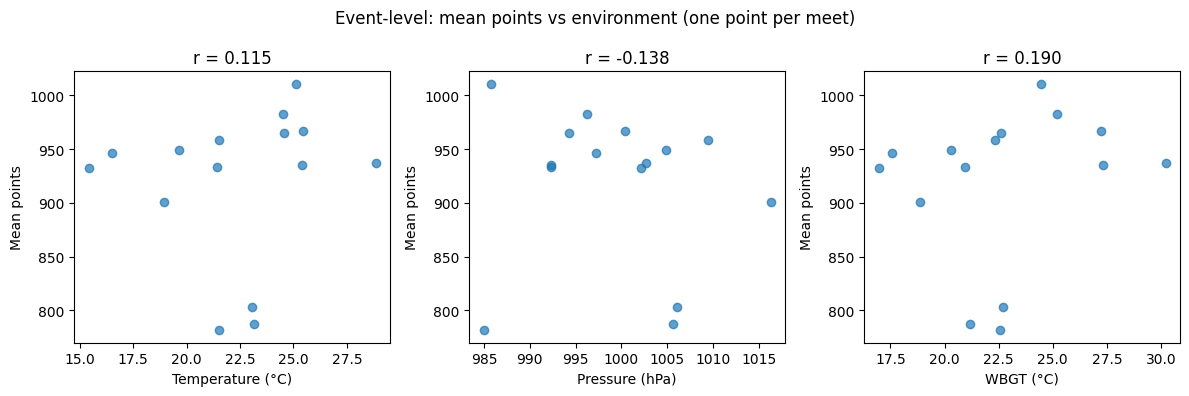

In [ ]:
# Scatter plot: mean event time vs temperature / pressure / WBGT

import matplotlib.pyplot as plt

# Pick an event with enough meets (e.g. Men's 100m Freestyle)
event_counts = agg.groupby(["discipline_name", "gender"]).size()
pick = event_counts[event_counts >= 8].index[0] if (event_counts >= 8).any() else event_counts.index[0]
g = agg[(agg["discipline_name"] == pick[0]) & (agg["gender"] == pick[1])].copy()
print(f"Plotting {pick[0]} ({pick[1]}), n={len(g)}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, label in zip(axes, ["temperature", "pressure", "wbgt"], ["Temperature (°C)", "Pressure (hPa)", "WBGT (°C)"]):
    ax.scatter(g[col], g["points"], alpha=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel("Mean points")
    r = g["points"].corr(g[col])
    ax.set_title(f"r = {r:.3f}")
plt.suptitle("Event-level: mean points vs environment (one point per meet)")
plt.tight_layout()
plt.show()

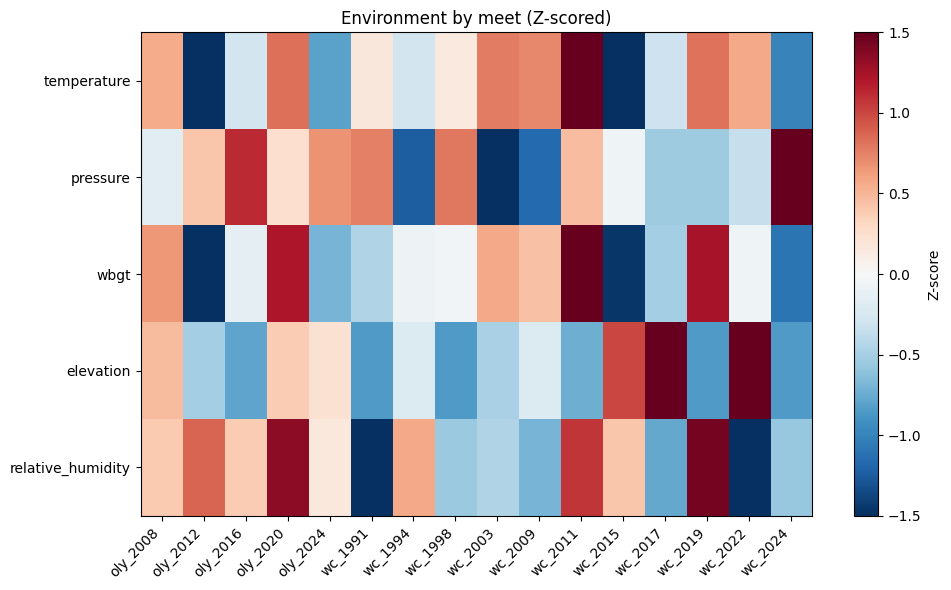

In [10]:
# Heatmap: env vars by meet (standardized)
env_cols = ["temperature", "pressure", "wbgt", "elevation", "relative_humidity"]
meet_env = df.groupby("meet_id")[env_cols].first()
meet_env_z = (meet_env - meet_env.mean()) / meet_env.std()
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(meet_env_z.T, aspect="auto", cmap="RdBu_r", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(len(meet_env)))
ax.set_xticklabels(meet_env.index, rotation=45, ha="right")
ax.set_yticks(range(len(env_cols)))
ax.set_yticklabels(env_cols)
plt.colorbar(im, ax=ax, label="Z-score")
ax.set_title("Environment by meet (Z-scored)")
plt.tight_layout()
plt.show()

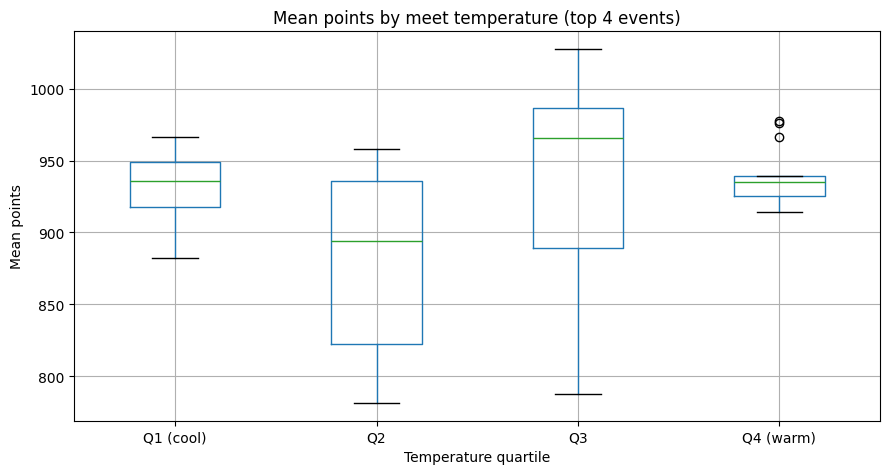

In [11]:
# Box plot: mean race time by temperature quartile (event-level)
agg_copy = agg.dropna(subset=["temperature"]).copy()
agg_copy["temp_quartile"] = pd.qcut(agg_copy["temperature"], 4, labels=["Q1 (cool)", "Q2", "Q3", "Q4 (warm)"])
top_events = agg_copy.groupby(["discipline_name", "gender"]).size().nlargest(4).index.tolist()
agg_top = agg_copy[agg_copy.set_index(["discipline_name", "gender"]).index.isin(top_events)]
fig, ax = plt.subplots(figsize=(9, 5))
agg_top.boxplot(column="points", by="temp_quartile", ax=ax)
ax.set_xlabel("Temperature quartile")
ax.set_ylabel("Mean points")
ax.set_title("Mean points by meet temperature (top 4 events)")
plt.suptitle("")
plt.tight_layout()
plt.show()

/var/folders/jb/htz2wz0x3s93z17kl82cw22c0000gn/T/ipykernel_33123/2936389828.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([agg6.loc[agg6["event"] == e, "points"].values for e in event_order],


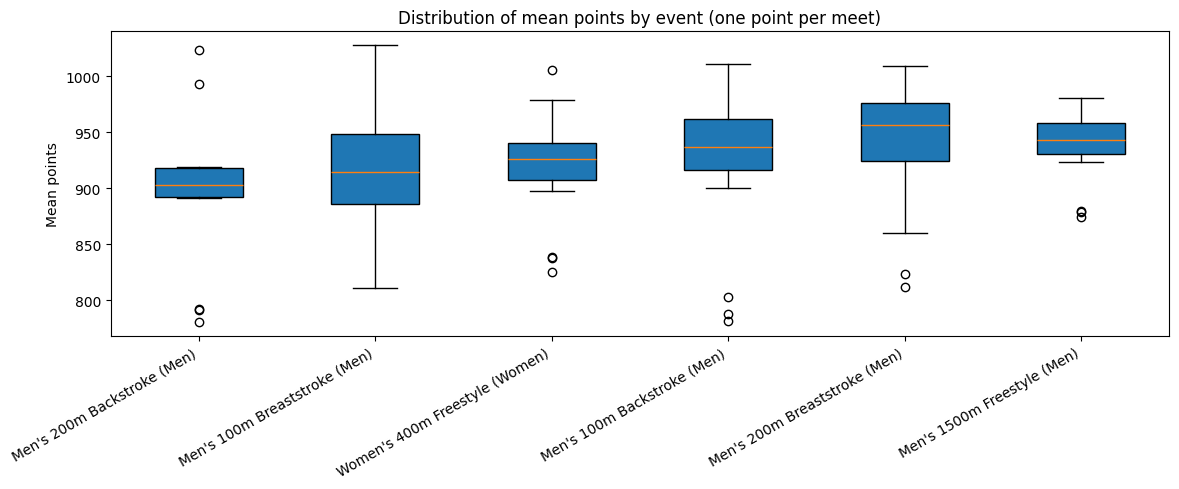

In [12]:
# Mean time distribution by event (box plot)
top6 = agg.groupby(["discipline_name", "gender"]).size().nlargest(6).index.tolist()
agg6 = agg[agg.set_index(["discipline_name", "gender"]).index.isin(top6)].copy()
agg6["event"] = agg6["discipline_name"] + " (" + agg6["gender"] + ")"
event_order = agg6.groupby("event")["points"].mean().sort_values().index.tolist()
agg6 = agg6[agg6["event"].isin(event_order)]
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot([agg6.loc[agg6["event"] == e, "points"].values for e in event_order],
                labels=event_order, patch_artist=True)
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")
ax.set_ylabel("Mean points")
ax.set_title("Distribution of mean points by event (one point per meet)")
plt.tight_layout()
plt.show()

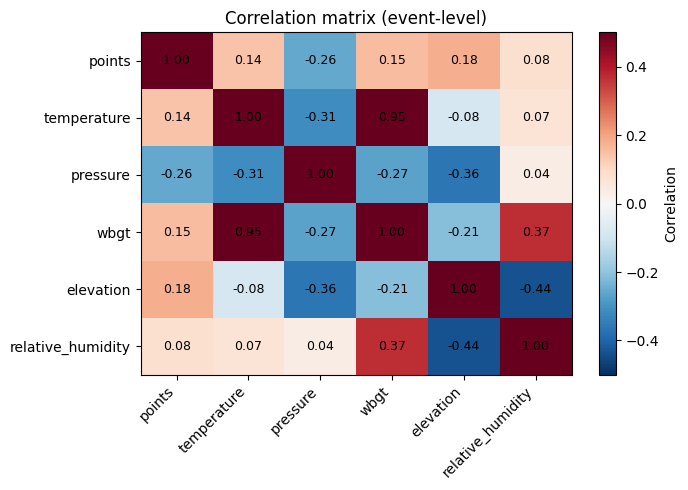

In [13]:
# Correlation heatmap: env vars + mean time (event-level)
cols = ["points", "temperature", "pressure", "wbgt", "elevation", "relative_humidity"]
corr_mat = agg[cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_mat, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr_mat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation matrix (event-level)")
plt.tight_layout()
plt.show()

In [14]:
# Summary: correlation by env variable (averaged across events that have enough meets)
summary = corr_df.groupby("env")["corr"].agg(["mean", "std", "count"]).round(4)
summary

,mean,std,count
env,,,
elevation,0.1404,0.1621,40
pressure,-0.3402,0.2383,40
relative_humidity,0.0300,0.2050,40
temperature,0.1707,0.1216,40
wbgt,0.1672,0.0954,40
